<a href="https://colab.research.google.com/github/AbdulHanoos/Drive_Guard/blob/main/Driver_Distraction_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle .json to kaggle .json


{'kaggle .json': b'{"username":"akahanoos","key":"ed9ffbc8779815cf9c121113d3eb2859"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp "kaggle .json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!ls ~/.kaggle

kaggle.json


In [6]:
!kaggle competitions download -c state-farm-distracted-driver-detection -p /content/distracted_driver_data

100% 4.00G/4.00G [03:57<00:00, 18.1MB/s]



In [7]:
!unzip -q /content/distracted_driver_data/state-farm-distracted-driver-detection.zip -d /content/distracted_driver_data/state-farm-distracted-driver-detection

In [8]:
import os

train_path = "/content/distracted_driver_data/state-farm-distracted-driver-detection/imgs/train"

classes = sorted([
    cls for cls in os.listdir(train_path)
    if os.path.isdir(os.path.join(train_path, cls))
])

print("Classes found:", classes)
print("Number of classes:", len(classes))

for cls in classes:
    class_path = os.path.join(train_path, cls)
    image_count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(cls, ":", image_count)

Classes found: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Number of classes: 10
c0 : 2489
c1 : 2267
c2 : 2317
c3 : 2346
c4 : 2326
c5 : 2312
c6 : 2325
c7 : 2002
c8 : 1911
c9 : 2129


In [9]:
import os
import cv2
import numpy as np
import tensorflow as tf
from imutils import paths
import random
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.utils import img_to_array


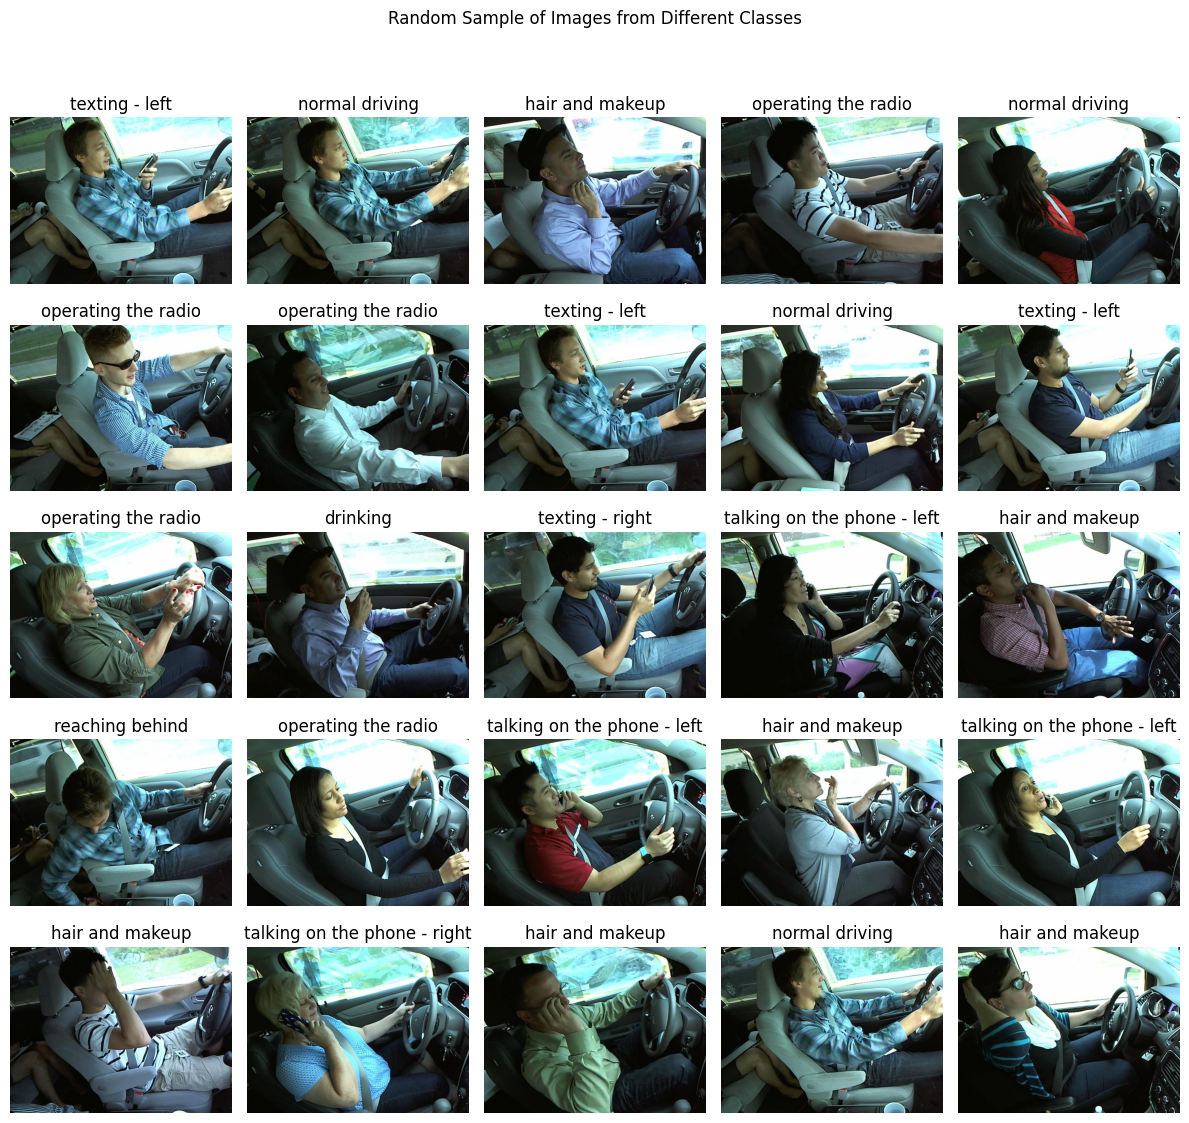

In [10]:
imagePaths = list(paths.list_images("/content/distracted_driver_data/state-farm-distracted-driver-detection/imgs/train"))
classnames = {
    "c0": "normal driving",
    "c1": "texting - right",
    "c2": "talking on the phone - right",
    "c3": "texting - left",
    "c4": "talking on the phone - left",       # Fixed: was "right"
    "c5": "operating the radio",               # Fixed: typo "ratio"
    "c6": "drinking",
    "c7": "reaching behind",
    "c8": "hair and makeup",
    "c9": "talking to passenger"
}

def display_images(image_paths, title, cols=5, num_images=25):  # Set cols and add num_images
    random.shuffle(image_paths)  # Shuffle the image paths randomly
    num_images = min(len(image_paths), num_images)  # Limit the number of images to display
    rows = (num_images + cols - 1) // cols

    plt.figure(figsize=(12, 12))  # Adjust figure size to accommodate more rows
    plt.suptitle(title)

    for i, image_path in enumerate(image_paths[:num_images]):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(image_path)
        plt.imshow(img,cmap = "gray")
        label = classnames.get(os.path.basename(os.path.dirname(image_path)))
        plt.title(label)
        plt.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Display a random set of images in a 5x5 grid
display_images(imagePaths, title="Random Sample of Images from Different Classes", num_images=25)


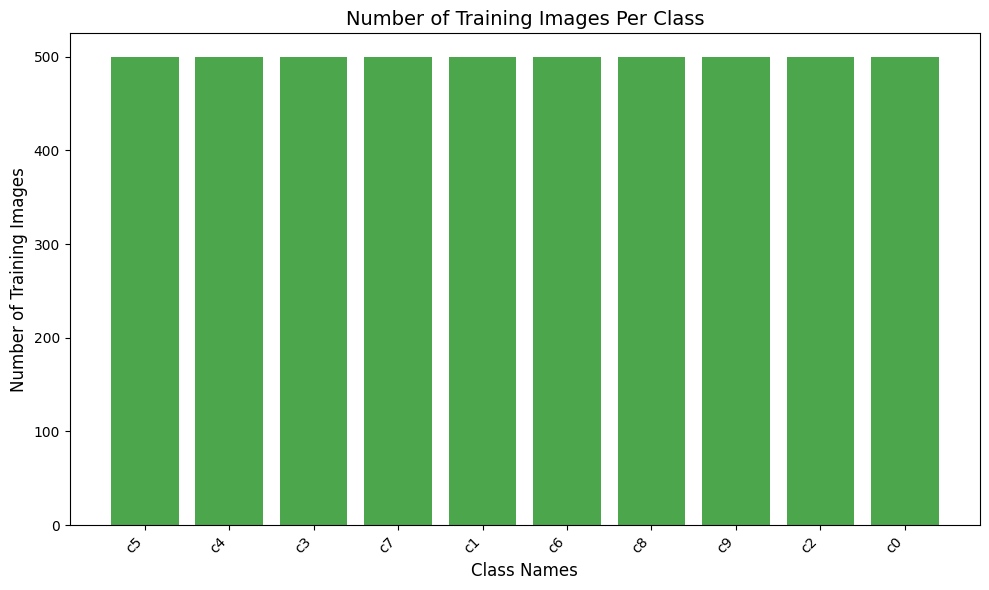

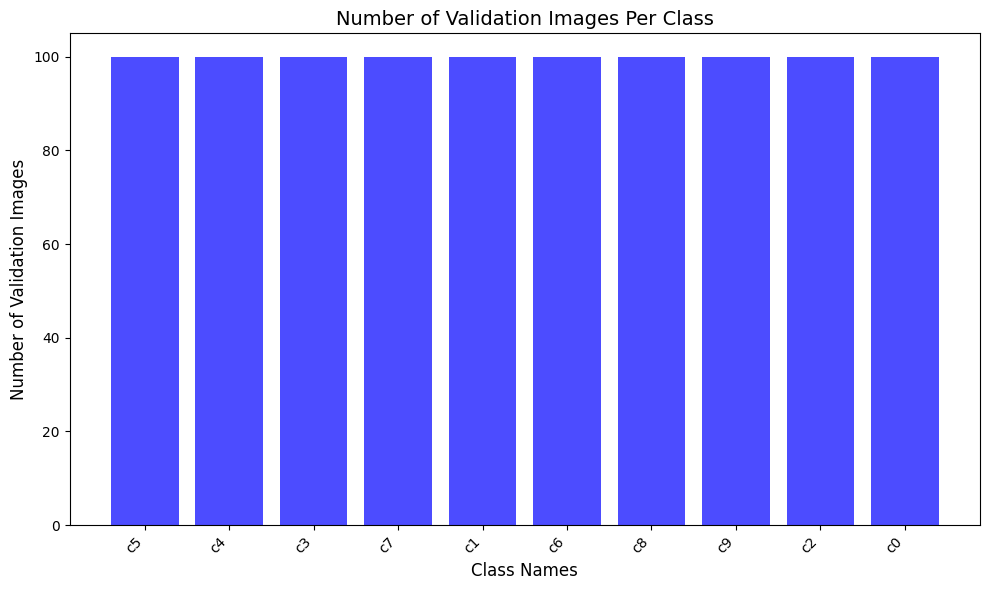

In [11]:
import os
import random
import matplotlib.pyplot as plt

# Folder containing all classes
data_folder = "/content/distracted_driver_data/state-farm-distracted-driver-detection/imgs/train"

# Number of images needed for train and validation
train_count = 500
val_count = 100

# Dictionary to store train and validation paths
train_paths = {cls: [] for cls in os.listdir(data_folder)}
val_paths = {cls: [] for cls in os.listdir(data_folder)}

# Iterate through each class folder
for cls in train_paths.keys():
    class_folder = os.path.join(data_folder, cls)
    if os.path.isdir(class_folder):
        # Get all image paths in the class folder
        images = [os.path.join(class_folder, img) for img in os.listdir(class_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
        # Shuffle the images to randomize the selection
        random.shuffle(images)
        # Split into train and validation
        train_paths[cls] = images[:train_count]
        val_paths[cls] = images[train_count:train_count + val_count]

# Count images per class for train and validation
train_counts = {cls: len(paths) for cls, paths in train_paths.items()}
val_counts = {cls: len(paths) for cls, paths in val_paths.items()}

# Visualization: Bar plot for training image counts
plt.figure(figsize=(10, 6))
plt.bar(train_counts.keys(), train_counts.values(), color='green', alpha=0.7)
plt.xlabel("Class Names", fontsize=12)
plt.ylabel("Number of Training Images", fontsize=12)
plt.title("Number of Training Images Per Class", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

# Visualization: Bar plot for validation image counts
plt.figure(figsize=(10, 6))
plt.bar(val_counts.keys(), val_counts.values(), color='blue', alpha=0.7)
plt.xlabel("Class Names", fontsize=12)
plt.ylabel("Number of Validation Images", fontsize=12)
plt.title("Number of Validation Images Per Class", fontsize=14)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

In [12]:
import cv2
import os
import numpy as np

class SimpleDatasetLoader:
  def __init__(self, preprocessors=None):
    self.preprocessors = preprocessors
    if self.preprocessors is None:
      self.preprocessors = []

  def load(self, imagePaths, verbose =- 1):
  # initialize the list of features and labels
    data = []
    labels = []

    for (i, imagePath) in enumerate(imagePaths):
      image = cv2.imread(imagePath)
      label = imagePath.split(os.path.sep)[-2]

# check to see if our preprocessors are not None
      if self.preprocessors is not None:
        for p in self.preprocessors:
          image = p.preprocess(image)

# treat our processed image as a "feature vector"
# by updating the data list followed by the labels
      data.append(image)
      labels.append(label)
      #-show.an update-every 'verbose" . images
      if verbose > 0 and i > 0 and (i + 1) % verbose == 0:
        print("[INFO] processed {}/{}".format(i +1,
          len(imagePaths)))

# return a tuple of the data and labels
    return (np.array(data), np.array(labels))

In [13]:
import cv2
class SimplePreprocessor:
    def __init__(self, width, height, inter=cv2.INTER_AREA):
        self.width = width
        self.height = height
        self.inter = inter

    def preprocess(self, image):
      return cv2.resize(image, (self.width, self.height),
                        interpolation=self.inter)



In [14]:
from tensorflow.keras.preprocessing.image import img_to_array

class ImageToArrayPreprocessor:
    def __init__(self, dataFormat=None):
        self.dataFormat = dataFormat

    def preprocess(self, image):
        return img_to_array(image, data_format=self.dataFormat)

In [15]:
 # initialize the image preprocessors
sp = SimplePreprocessor(128,128)
iap = ImageToArrayPreprocessor()

In [16]:

# Combine all training image paths into a single list
all_train_paths = [path for paths in train_paths.values() for path in paths]

# Combine all validation image paths into a single list (optional)
all_val_paths = [path for paths in val_paths.values() for path in paths]

# Output the size of the lists
print(f"Total training images: {len(all_train_paths)}")
print(f"Total validation images: {len(all_val_paths)}")

Total training images: 5000
Total validation images: 1000


In [17]:
iap = ImageToArrayPreprocessor()
sdl = SimpleDatasetLoader(preprocessors=[sp, iap])
(train_data, train_labels) = sdl.load(all_train_paths, verbose=1000)

[INFO] processed 1000/5000
[INFO] processed 2000/5000
[INFO] processed 3000/5000
[INFO] processed 4000/5000
[INFO] processed 5000/5000


In [18]:
(val_data, val_labels) = sdl.load(all_val_paths, verbose=500)

[INFO] processed 500/1000
[INFO] processed 1000/1000


In [ ]:
print(type(train_data))
print(train_data.shape)

print(type(val_data))
print(val_data.shape)

<class 'numpy.ndarray'>
(5000, 128, 128, 3)
<class 'numpy.ndarray'>
(1000, 128, 128, 3)


In [19]:
[ ] # Data Normalization for all-train and validatoin all.image
train_scaled_data = train_data.astype('float32')/255
val_scaled_data = val_data.astype('float32')/255

In [20]:


print(train_scaled_data.shape)
print(val_scaled_data.shape)
print(train_scaled_data.min(), train_scaled_data.max())
print(val_scaled_data.min(), val_scaled_data.max())

(5000, 128, 128, 3)
(1000, 128, 128, 3)
0.0 1.0
0.0 1.0


In [21]:
import pandas as pd
train_val_data = {'total data':[len(train_scaled_data),len(val_scaled_data),len(train_labels),len(val_labels)]}
pd.DataFrame.from_dict(train_val_data, orient='index',columns=["train_scaled_data","train_labels","val_scaled_data","val_labels"])

,train_scaled_data,train_labels,val_scaled_data,val_labels
total data,5000,1000,5000,1000


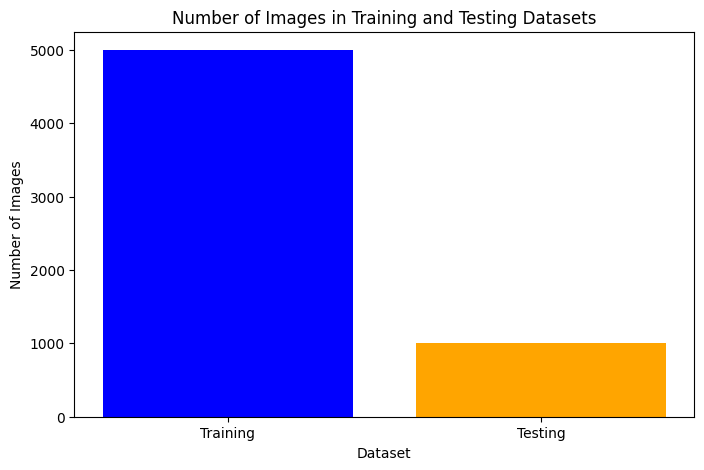

In [22]:
# Calculate the number of images for training and testing
import matplotlib.pyplot as plt
num_train_images = len(train_scaled_data)
num_test_images = len(val_scaled_data)
# Create a bar plot
plt.figure(figsize=(8, 5))
plt.bar(['Training', 'Testing'], [num_train_images, num_test_images], color=['blue', 'orange'])
plt.xlabel('Dataset')
plt.ylabel('Number of Images')
plt.title('Number of Images in Training and Testing Datasets')
plt.show()

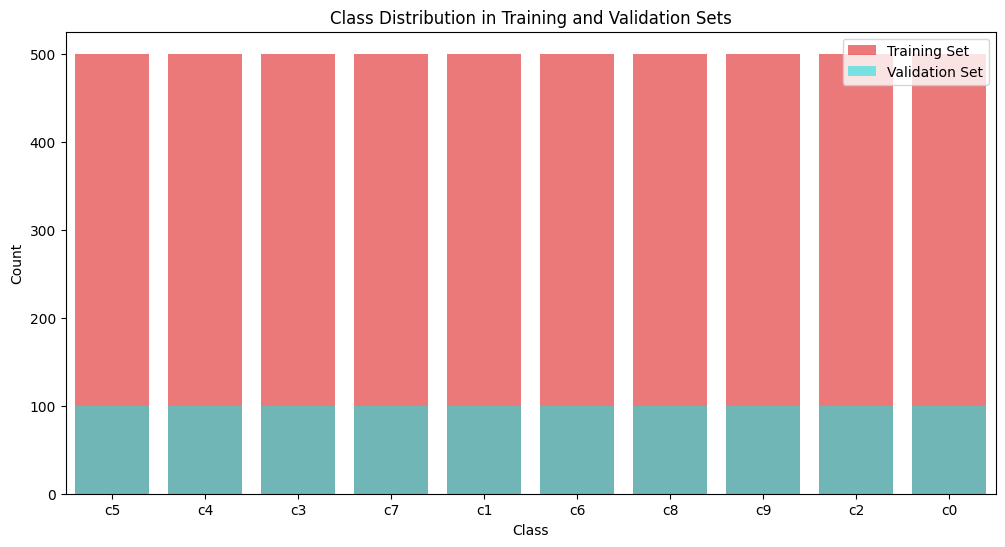

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Convert labels to DataFrames
train_df = pd.DataFrame({"Class": train_labels})
val_df = pd.DataFrame({"Class": val_labels})

plt.figure(figsize=(12, 6))

sns.countplot(
    x="Class",
    data=train_df,
    color="red",
    alpha=0.6,
    label="Training Set"
)

sns.countplot(
    x="Class",
    data=val_df,
    color="cyan",
    alpha=0.6,
    label="Validation Set"
)

plt.title("Class Distribution in Training and Validation Sets")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend()
plt.show()

In [24]:
from sklearn.preprocessing import LabelBinarizer
y_train_label = LabelBinarizer().fit_transform(train_labels)
y_test_label = LabelBinarizer().fit_transform(val_labels)

In [25]:
y_train_label

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]])

In [26]:
import os
import h5py
import math
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, load_model
from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from IPython.display import SVG
from tensorflow.keras.utils import plot_model
from tensorflow.keras.initializers import glorot_uniform
import scipy.misc
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from tensorflow.keras.optimizers import Adam
%matplotlib inline
import tensorflow.keras.backend as K
K.set_image_data_format('channels_last')
TF_USE_LEGACY_KERAS=True

In [27]:
def identity_block(X, f, filters, stage, block):
# defining base name for block
    conv_base_name = 'res' + str(stage) + block + '_'
    bn_base_name = 'bn' + str(stage) + block + '_'

# retrieve number of filters in each layer of main
# NOTE: f3 must be equal to n_C. That way dimensio
    f1, f2, f3 = filters

# Batch normalization must be performed on the 'ch
    bn_axis = 3

# save input for "addition" to last layer output;
    X_skip_connection = X
    X = Conv2D(filters= f1, kernel_size = (1,1), strides = (1,1), padding='valid', name=conv_base_name+'first_component', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=bn_axis, name=bn_base_name+'first_component')(X)
    X = Activation('relu')(X)

# Second component/layer of main path
    X = Conv2D(filters= f2, kernel_size = (f,f), strides = (1,1), padding='same', name=conv_base_name+'second_component', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=bn_axis, name=bn_base_name+'second_component')(X)
    X = Activation('relu')(X)

# Third component/layer of main path
    X = Conv2D(filters= f3, kernel_size = (1,1), strides = (1,1), padding='valid', name=conv_base_name+'third_component', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=bn_axis, name=bn_base_name+'third_component')(X)

# "Addition step" - skip-connection value merges with main path
# NOTE: both values have same dimensions at this point, so no operation is required to match dimensions
    X = Add()([X, X_skip_connection])
    X = Activation('relu')(X)

    return X

In [28]:
def convolutional_block(X, f, filters, stage, block, s = 2):
    conv_base_name = 'res' + str(stage) + block +'_'
    bn_base_name = 'bn' + str(stage) + block + '_'

# retrieve number of filters in each layer of main path
    f1, f2, f3 = filters

# Batch normalization must be performed on the 'channels' axis for input. It is 3, for our case
    bn_axis = 3

# save input for "addition" to last layer output; step in skip-connection
    X_skip_connection = X

##### MAIN PATH #####
# First component of main path
    X = Conv2D(f1,(1, 1), strides = (s,s), padding = 'valid', name = conv_base_name + 'first_component', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = bn_axis, name = bn_base_name + 'first_component')(X)
    X = Activation('relu') (X)

# Second component of main path
    X = Conv2D(f2, kernel_size = (f, f), strides = (1,1), padding ='same', name= conv_base_name+'second_component', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = bn_axis, name = bn_base_name + 'second_component')(X)
    X = Activation('relu') (X)

# Third component of main path
    X = Conv2D(f3, kernel_size  = (1, 1), strides = (1,1), padding = 'valid', name = conv_base_name + 'third_component', kernel_initializer = glorot_uniform(seed= 0))(X)
    X = BatchNormalization(axis = bn_axis, name = bn_base_name + 'third_component')(X)

##### Convolve skip-connection value to match its dimensions to third layer output's dimensions ####
    X_skip_connection = Conv2D(f3, (1, 1), strides = (s,s), padding = 'valid', name = conv_base_name + 'merge', kernel_initializer = glorot_uniform(seed=0))(X_skip_connection)
    X_skip_connection = BatchNormalization(axis = 3, name = bn_base_name + 'merge')(X_skip_connection)

# "Addition step"
# NOTE: both values have same dimensions at this point
    X = Add()([X, X_skip_connection])
    X = Activation('relu') (X)

    return X

In [29]:
def ResNet50(input_shape,classes ):

# plug in input_shape to define the input tensor
    X_input = Input(input_shape)

# Zero-Padding : pads the input with a pad of (3,3)
    X = ZeroPadding2D((3, 3))(X_input)

# Stage 1
    X = Conv2D(64, (7, 7), strides = (2, 2), name = 'conv_1', kernel_initializer = glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis = 3, name = 'bn_1')(X)
    X = Activation('relu') (X)
    X = MaxPooling2D((3, 3), strides=(2, 2))(X)

# NOTE: dimensions of filters that are passed to identity block are such that final layer output
# in identity block mathces the original input to the block
# blocks in each stage are alphabetically sequenced

# Stage 2
    X = convolutional_block(X, f = 3, filters = [64, 64, 256], stage = 2, block='a', s = 1)
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='b')
    X = identity_block(X, 3, [64, 64, 256], stage=2, block='c')

# Stage 3
    X = convolutional_block(X, f=3, filters=[128, 128, 512], stage=3, block='a', s=2)
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='b')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='c')
    X = identity_block(X, 3, [128, 128, 512], stage=3, block='d')

# Stage 4
    X = convolutional_block(X, f=3, filters=[256, 256, 1024], stage=4, block='a', s=2)
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='b')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='c')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='d')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='e')
    X = identity_block(X, 3, [256, 256, 1024], stage=4, block='f')

# Stage 5
    X = convolutional_block(X, f=3, filters=[512, 512, 2048], stage=5, block='a', s=2)
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='b')
    X = identity_block(X, 3, [512, 512, 2048], stage=5, block='c')

# Average Pooling
    X = AveragePooling2D((2, 2), name='avg_pool')(X)

# output layer
    X = Flatten()(X)
    X = Dense(512, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
    X = Dense(256, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
    X = Dense(128, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
    X = Dense(64, activation='relu', kernel_initializer=glorot_uniform(seed=0))(X)
    X = Dense(classes, activation='softmax', name='fc' + str(classes), kernel_initializer=glorot_uniform(seed=0))(X)
# Create model
    model = Model(inputs = X_input, outputs = X, name='ResNets50')

    return model

In [30]:
model = ResNet50(input_shape = (128,128, 3), classes = 10)
model.compile(optimizer=Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "ResNets50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 134, 134,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 64, 64,    │      9,472 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 64, 64,    │        256 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ bn_1[0][0]        │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 31, 31,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_first_compon… │ (None, 31, 31,    │      4,160 │ max_pooling2d[0]… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_first_compone… │ (None, 31, 31,    │        256 │ res2a_first_comp… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 31, 31,    │          0 │ bn2a_first_compo… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_second_compo… │ (None, 31, 31,    │     36,928 │ activation_1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_second_compon… │ (None, 31, 31,    │        256 │ res2a_second_com… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 31, 31,    │          0 │ bn2a_second_comp… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_third_compon… │ (None, 31, 31,    │     16,640 │ activation_2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2a_merge         │ (None, 31, 31,    │     16,640 │ max_pooling2d[0]… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_third_compone… │ (None, 31, 31,    │      1,024 │ res2a_third_comp… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn2a_merge          │ (None, 31, 31,    │      1,024 │ res2a_merge[0][0] │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 31, 31,    │          0 │ bn2a_third_compo

 Total params: 27,955,658 (106.64 MB)

 Trainable params: 27,902,538 (106.44 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [31]:
from tensorflow.keras.callbacks import ModelCheckpoint
import pickle

checkpoint = ModelCheckpoint(
    filepath="/content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.weights.h5",
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

history = model.fit(
    train_scaled_data,
    y_train_label,
    batch_size=8,   # use 8 for GPU safety
    epochs=10,
    validation_data=(val_scaled_data, y_test_label),
    callbacks=[checkpoint]
)

with open("/content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.pkl", "wb") as file:
    pickle.dump(history.history, file)

print("ResNet-50 classification model trained, and best weights saved!")

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.1169 - loss: 2.3734
Epoch 1: val_accuracy improved from None to 0.20900, saving model to /content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.weights.h5

Epoch 1: finished saving model to /content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.weights.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 106s 78ms/step - accuracy: 0.1556 - loss: 2.2655 - val_accuracy: 0.2090 - val_loss: 2.2976
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.4436 - loss: 1.5406
Epoch 2: val_accuracy improved from 0.20900 to 0.24200, saving model to /content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.weights.h5

Epoch 2: finished saving model to /content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.weights.h5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 68ms/step - accuracy: 0.5522 - loss: 1.2564 - val_accuracy: 0.2420 - val_loss: 3.8917
Epoch 3/

In [32]:
# evaluate the network on the fine-tuned model
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report
# Load the weights
model.load_weights('/content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.weights.h5')
print("Model-weights loaded successfully!")

print("[INFO] evaluating after fine-tuning ... ")
predictions = model.predict(val_scaled_data, batch_size=16)
classNames = names = [
"safe driving",
"texting - right",
"talking on the phone - right",
"texting - left",
"talking on the phone - left",
"operating the radio",
"drinking",
"reaching behind",
"hair and makeup",
"talking to passenger"

]

print(classification_report(y_test_label.argmax(axis=1),
predictions.argmax(axis=1), target_names=classNames))

Model-weights loaded successfully!
[INFO] evaluating after fine-tuning ... 
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 90ms/step
                              precision    recall  f1-score   support

                safe driving       0.93      0.94      0.94       100
             texting - right       0.97      0.97      0.97       100
talking on the phone - right       0.94      0.99      0.97       100
              texting - left       0.97      0.94      0.95       100
 talking on the phone - left       0.99      0.98      0.98       100
         operating the radio       0.97      0.98      0.98       100
                    drinking       0.99      0.92      0.95       100
             reaching behind       0.98      0.99      0.99       100
             hair and makeup       0.97      0.95      0.96       100
        talking to passenger       0.91      0.96      0.94       100

                    accuracy                           0.96      1000
                   macro avg       0.96  

Confusion Matrix:


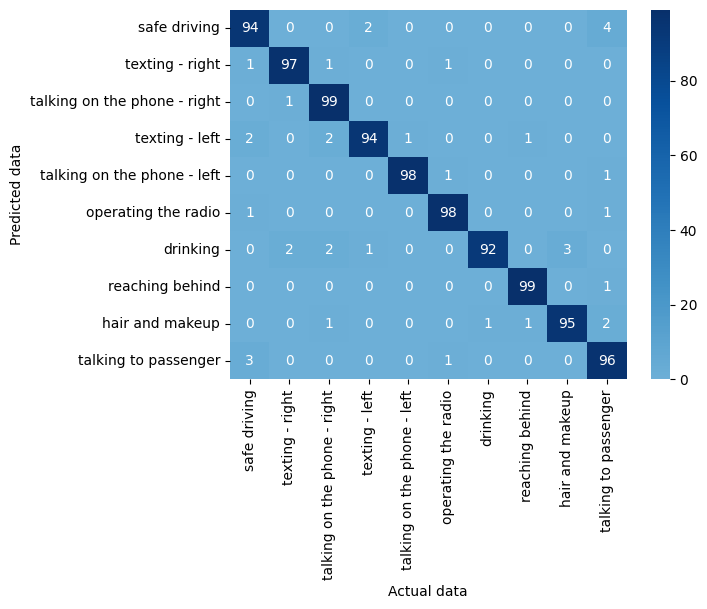

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
print("Confusion Matrix:")
classNames =[
"safe driving",
"texting - right",
"talking on the phone - right",
"texting - left",
"talking on the phone - left",
"operating the radio",
"drinking",
"reaching behind",
"hair and makeup",
"talking to passenger"

]

CM = confusion_matrix(y_test_label.argmax(axis=1),
predictions.argmax(axis=1))
# drawing confusion matrix
sns.heatmap(CM, center = True , annot=True, fmt="d" ,cmap="Blues", xticklabels=classNames, yticklabels=classNames)
plt.xlabel("Actual data")
plt.ylabel("Predicted data")
plt.show()

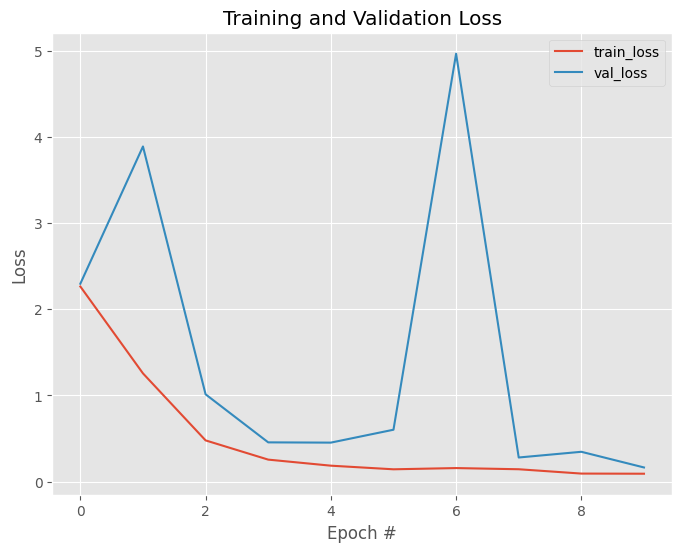

In [35]:
import pickle
# Load the processed dataset
pickle_file_path = '/content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.pkl'
with open(pickle_file_path, 'rb') as file:
  history = pickle.load(file)
plt.style.use("ggplot")
plt.figure(figsize=(8,6))
plt.plot(np.arange(0, len(history["loss"])),history["loss"], label="train_loss")
plt.plot(np.arange(0, len(history["val_loss"])), history["val_loss"], label="val_loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()
# plt.savefig("output.png")
plt.show()

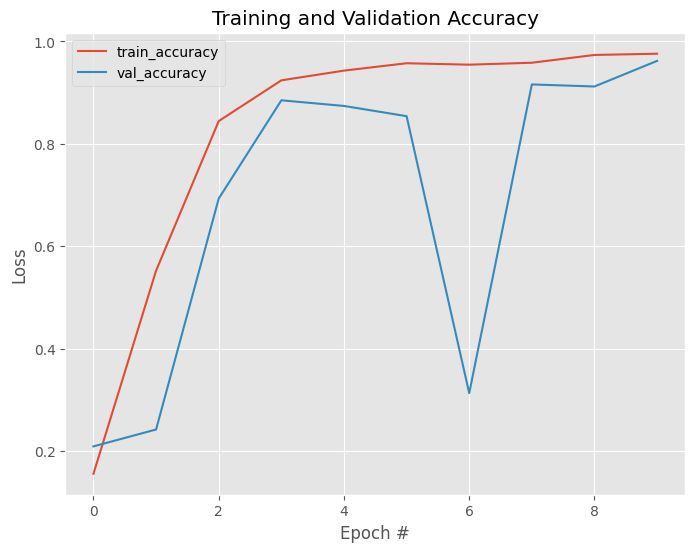

In [36]:
plt.style.use("ggplot")
plt.figure(figsize=(8,6))
plt.plot(np.arange(0, len(history["accuracy"])), history["accuracy"], label="train_accuracy")
plt.plot(np.arange(0, len(history["val_accuracy"])), history["val_accuracy"], label="val_accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch #")
plt.ylabel("Loss")
plt.legend()
# plt.savefig("output.png")
plt.show()

In [39]:
import cv2
class SimplePreprocessor:
  def __init__(self, width, height, inter=cv2.INTER_AREA):
# store the target image width, height, and interpolation
# method used when resizing
      self.width = width
      self.height = height
      self.inter = inter

  def preprocess(self, image):
# resize the image to a fixed size, ignoring the aspect
# ratio
      return cv2.resize(image, (self.width, self.height),
          interpolation=self.inter)

In [40]:
sp = SimplePreprocessor(128, 128)

In [41]:
model.load_weights('/content/distracted_driver_data/state-farm-distracted-driver-detection/resnet_50.weights.h5')
print("Model weights loaded successfully")

Model weights loaded successfully


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


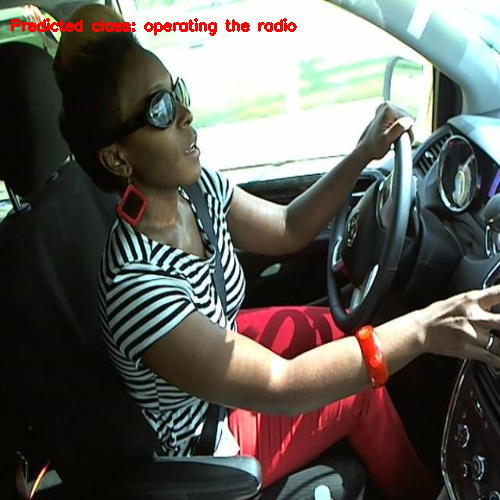

In [59]:
from google.colab.patches import cv2_imshow
import cv2
import numpy as np
# Load the image
image_path = "/content/distracted_driver_data/state-farm-distracted-driver-detection/imgs/test/img_100936.jpg"
image = cv2.imread(image_path)
# Preprocess the image
sp = SimplePreprocessor(128,128)
data = sp.preprocess(image)
data = data.astype("float") / 255.0
data = np.expand_dims(data, axis=0)

# Predict using the model
prediction = model.predict(data)
Name   = [
"safe driving",
"texting - right",
"talking on the phone - right",
"texting - left",
"talking on the phone - left",
"operating the radio",
"drinking",
"reaching behind",
"hair and makeup",
"talking to passenger"
]
predicted_class = Name[prediction.argmax()]

# Add text to the image
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 0.5
font_thickness = 2
text_color = (0,0,255) # Green color
text = f"Predicted class: {predicted_class}"
text_size = cv2.getTextSize(text, font, font_scale, font_thickness)[0]
resize_img= cv2.resize(image,(500,500))
cv2.putText(resize_img, text, (10,30), font, font_scale, text_color, font_thickness)
# Display the annotated image
cv2_imshow(resize_img)